In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scqubits as scq

# =========================
# 1. 创建 Transmon
# =========================
transmon = scq.Transmon(
    EJ=20.0,     # Josephson energy
    EC=0.3,      # Charging energy
    ng=0.0,      # offset charge
    ncut=30      # charge basis cutoff
)



In [4]:
# =========================
# 2. 打印能级
# =========================
evals = transmon.eigenvals(evals_count=5)
print("Energy levels (GHz):")
for i, e in enumerate(evals):
    print(f"E{i} = {e:.4f} GHz")



Energy levels (GHz):
E0 = -16.6126 GHz
E1 = -9.9992 GHz
E2 = -3.7226 GHz
E3 = 2.1835 GHz
E4 = 7.6641 GHz


 /home/fanshaoze/.local/lib/python3.10/site-packages/matplotlib/cbook.py: 1719ComplexWarning: Casting complex values to real discards the imaginary part
 /home/fanshaoze/.local/lib/python3.10/site-packages/matplotlib/cbook.py: 1355

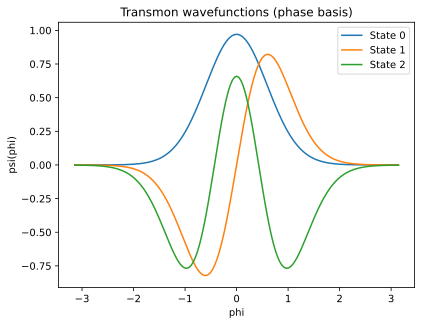

In [5]:
# =========================
# 3. 画波函数（phase basis）
# =========================
phi = np.linspace(-np.pi, np.pi, 200)

fig, ax = plt.subplots()

for i in range(3):
    wf = transmon.wavefunction(which=i)
    
    phi = wf.basis_labels   # φ 网格
    psi = wf.amplitudes     # 波函数值
    
    ax.plot(phi, psi, label=f"State {i}")

ax.set_title("Transmon wavefunctions (phase basis)")
ax.set_xlabel("phi")
ax.set_ylabel("psi(phi)")
ax.legend()
plt.show()



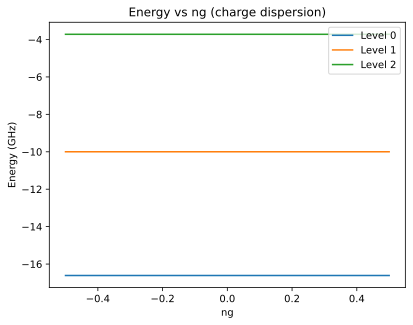

In [6]:
# =========================
# 4. 能级 vs ng（charge dispersion）
# =========================
ng_list = np.linspace(-0.5, 0.5, 50)

energies = []
for ng in ng_list:
    transmon.ng = ng
    energies.append(transmon.eigenvals(evals_count=3))

energies = np.array(energies)

fig, ax = plt.subplots()

for i in range(3):
    ax.plot(ng_list, energies[:, i], label=f"Level {i}")

ax.set_title("Energy vs ng (charge dispersion)")
ax.set_xlabel("ng")
ax.set_ylabel("Energy (GHz)")
ax.legend()
plt.show()